Airline Sentiment — Data Loading & EDA

**Goal:** Load the Twitter US Airline Sentiment dataset, clean the tweet text, and explore
sentiment patterns before building any models.

Sections:
1. Load data
2. Basic checks
3. Clean tweet text
4. Sentiment distribution
5. Sentiment by airline
6. Negative reason breakdown
7. Tweet length and word frequency
8. Key takeaways

In [41]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load Data

**Option A (recommended, no Kaggle account needed):** load directly from Hugging Face.
**Option B:** download `Tweets.csv` from Kaggle into `data/` and load locally.

In [29]:
df = pd.read_csv('Tweets.csv')
print(df.shape)
df.head()

(14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 2. Basic Checks

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

In [31]:
print('Missing values:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values:
negativereason_gold          14608
airline_sentiment_gold       14600
tweet_coord                  13621
negativereason                5462
user_timezone                 4820
tweet_location                4733
negativereason_confidence     4118
airline                          0
tweet_id                         0
airline_sentiment                0
dtype: int64


In [32]:
print('Airlines covered:', df['airline'].unique())
print('\nSentiment classes:', df['airline_sentiment'].unique())

Airlines covered: <ArrowStringArray>
['Virgin America', 'United', 'Southwest', 'Delta', 'US Airways', 'American']
Length: 6, dtype: str

Sentiment classes: <ArrowStringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str


## 3. Clean Tweet Text

Strip @mentions, URLs, and HTML entities, then lowercase. Keep the raw text column alongside
the cleaned version so you have real examples for your write-up.

In [33]:
def clean_tweet(text):
    text = str(text)
    text = re.sub(r'@\w+', '', text)               # remove @mentions
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'&\w+;', ' ', text)               # remove HTML entities like &amp;
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)         # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    return text.lower()

df['text_clean'] = df['text'].apply(clean_tweet)

df[['text', 'text_clean']].head(10)

,text,text_clean
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus you ve added commercials to the experienc...
2,@VirginAmerica I didn't today... Must mean I n...,i didn t today must mean i need to take anothe...
3,@VirginAmerica it's really aggressive to blast...,it s really aggressive to blast obnoxious ente...
4,@VirginAmerica and it's a really big bad thing...,and it s a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i didn t but now i do d
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early you r...


## 4. Sentiment Distribution

Check the class imbalance up front — this will shape which evaluation metrics matter later.

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64


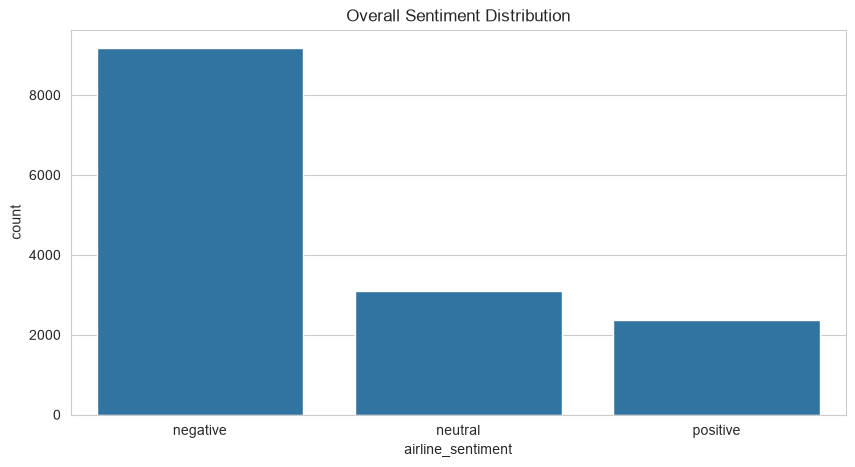

In [34]:
sentiment_counts = df['airline_sentiment'].value_counts()
sentiment_pct = df['airline_sentiment'].value_counts(normalize=True) * 100

print(sentiment_counts)
print(sentiment_pct.round(1))

sns.countplot(data=df, x='airline_sentiment', order=['negative', 'neutral', 'positive'])
plt.title('Overall Sentiment Distribution')
plt.show()

## 5. Sentiment by Airline

Both raw counts and normalized (%) views matter here — an airline with more tweets isn't
necessarily worse, it might just be bigger or more actively discussed.

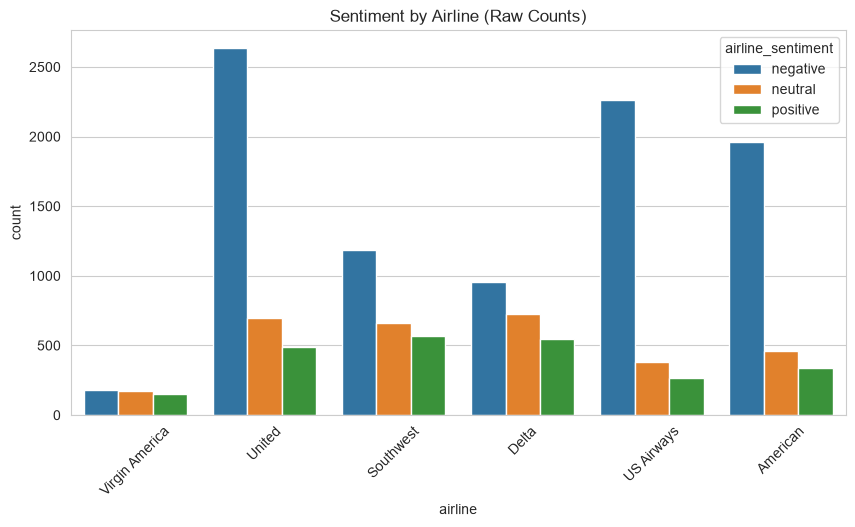

In [35]:
sns.countplot(data=df, x='airline', hue='airline_sentiment',
              hue_order=['negative', 'neutral', 'positive'])
plt.title('Sentiment by Airline (Raw Counts)')
plt.xticks(rotation=45)
plt.show()

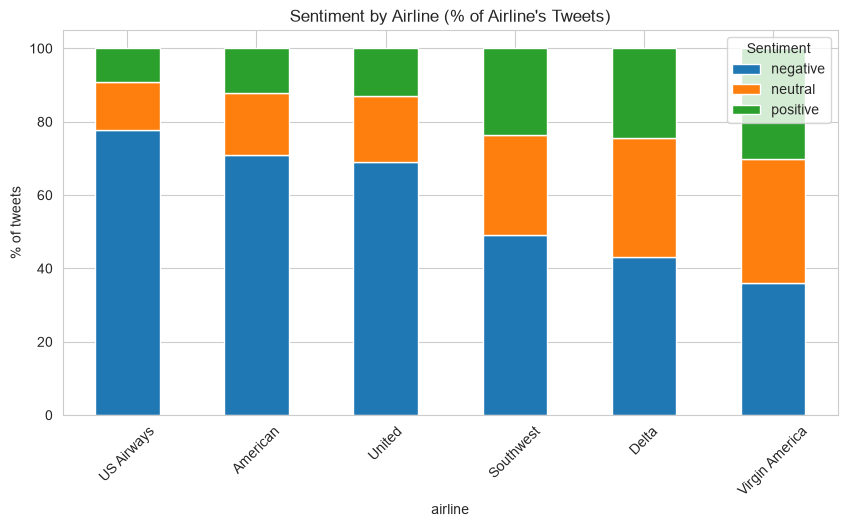

airline_sentiment,negative,neutral,positive
airline,,,
US Airways,77.686234,13.079300,9.234466
American,71.040232,16.781443,12.178325
United,68.890633,18.236525,12.872841
Southwest,49.008264,27.438017,23.553719
Delta,42.979298,32.538254,24.482448
Virgin America,35.912698,33.928571,30.158730


In [36]:
# Normalized view: % of each airline's tweets that are negative
normalized = pd.crosstab(df['airline'], df['airline_sentiment'], normalize='index') * 100
normalized = normalized.sort_values('negative', ascending=False)

normalized.plot(kind='bar', stacked=True)
plt.title('Sentiment by Airline (% of Airline\'s Tweets)')
plt.ylabel('% of tweets')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.show()

normalized

## 6. Negative Reason Breakdown

This is the diagnostic angle: WHY are people unhappy, not just that they are.

negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64


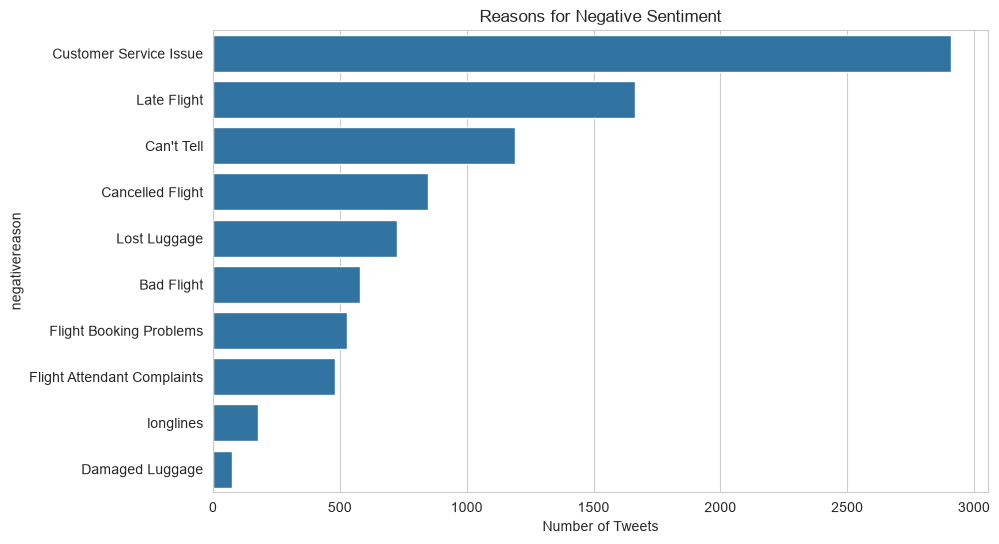

In [37]:
reason_counts = df['negativereason'].value_counts()
print(reason_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=reason_counts.values, y=reason_counts.index)
plt.title('Reasons for Negative Sentiment')
plt.xlabel('Number of Tweets')
plt.show()

In [38]:
# Top negative reason per airline
reason_by_airline = pd.crosstab(df['airline'], df['negativereason'])
top_reason_per_airline = reason_by_airline.idxmax(axis=1)
print(top_reason_per_airline)

airline
American          Customer Service Issue
Delta                        Late Flight
Southwest         Customer Service Issue
US Airways        Customer Service Issue
United            Customer Service Issue
Virgin America    Customer Service Issue
dtype: str


## 7. Tweet Length and Word Frequency

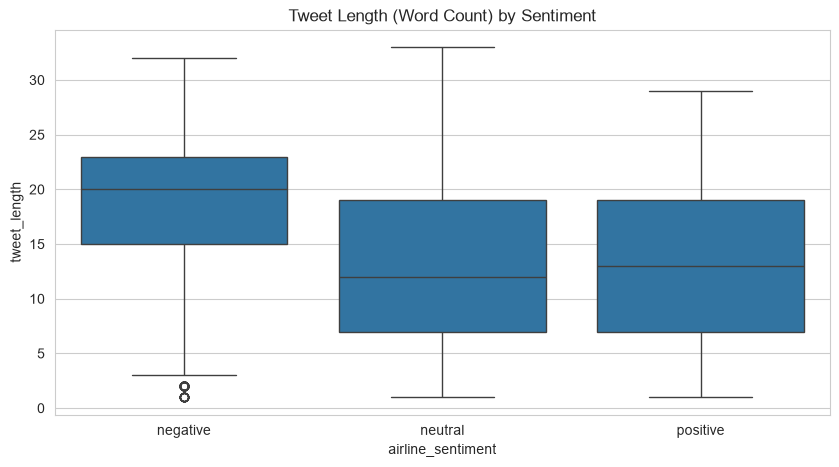

In [39]:
df['tweet_length'] = df['text_clean'].apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='airline_sentiment', y='tweet_length',
            order=['negative', 'neutral', 'positive'])
plt.title('Tweet Length (Word Count) by Sentiment')
plt.show()

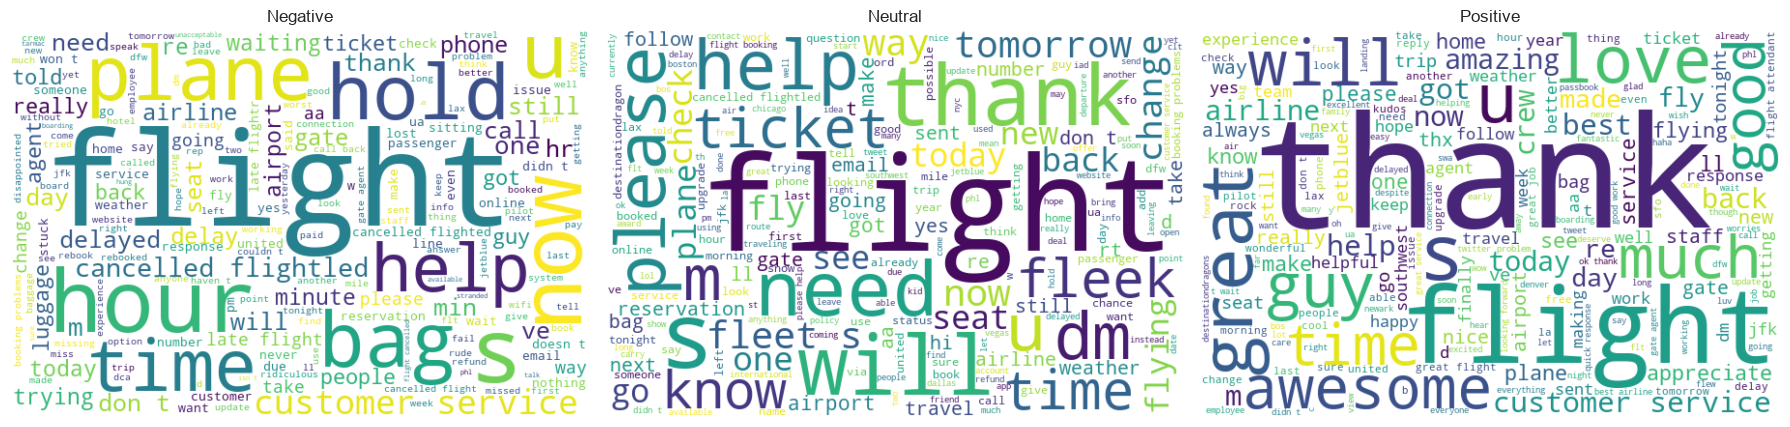

In [42]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    text = ' '.join(df[df['airline_sentiment'] == sentiment]['text_clean'])
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment.capitalize())
    ax.axis('off')

plt.tight_layout()
plt.show()